✅ Libraries ready!

Dataset


Saving laptopData.csv to laptopData.csv

✅ Loaded: laptopData.csv
   Rows    : 1303
   Columns : 12
   Nulls   : 360
   Dupes   : 29

First 5 rows:


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080



🔍 Date columns detected  : none
🔍 Email columns detected : none

  AutoCleaner running on: laptopData.csv
  → Renamed 12 columns → snake_case.
  → Removed 29 duplicate row(s).
  → Strings cleaned (strip=True, case=title).
  → Auto-converted 1 column(s) to numeric.
  → Filled 4 missing value(s) — numeric:median, cat:mode.
  → Outliers (iqr/clip): 73 value(s) handled.
✅ Done!

  Rows          : 1303  →  1274
  Columns       : 12  →  12
  Nulls         : 360  →  0
  Dupes removed : 29
  Outliers fixed: 73

Cleaned preview:


,unnamed_0,company,typename,inches,screenresolution,cpu,ram,memory,gpu,opsys,weight,price
0,0.0,Apple,Ultrabook,13.3,Ips Panel Retina Display 2560X1600,Intel Core I5 2.3Ghz,8Gb,128Gb Ssd,Intel Iris Plus Graphics 640,Macos,1.37Kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440X900,Intel Core I5 1.8Ghz,8Gb,128Gb Flash Storage,Intel Hd Graphics 6000,Macos,1.34Kg,47895.5232
2,2.0,Hp,Notebook,15.6,Full Hd 1920X1080,Intel Core I5 7200U 2.5Ghz,8Gb,256Gb Ssd,Intel Hd Graphics 620,No Os,1.86Kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,Ips Panel Retina Display 2880X1800,Intel Core I7 2.7Ghz,16Gb,512Gb Ssd,Amd Radeon Pro 455,Macos,1.83Kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,Ips Panel Retina Display 2560X1600,Intel Core I5 3.1Ghz,8Gb,256Gb Ssd,Intel Iris Plus Graphics 650,Macos,1.37Kg,96095.8080
5,5.0,Acer,Notebook,15.6,1366X768,Amd A9-Series 9420 3Ghz,4Gb,500Gb Hdd,Amd Radeon R5,Windows 10,2.1Kg,21312.0000
6,6.0,Apple,Ultrabook,15.4,Ips Panel Retina Display 2880X1800,Intel Core I7 2.2Ghz,16Gb,256Gb Flash Storage,Intel Iris Pro Graphics,Mac Os X,2.04Kg,114017.6016
7,7.0,Apple,Ultrabook,13.3,1440X900,Intel Core I5 1.8Ghz,8Gb,256Gb Flash Storage,Intel Hd Graphics 6000,Macos,1.34Kg,61735.5360
8,8.0,Asus,Ultrabook,14.0,Full Hd 1920X1080,Intel Core I7 8550U 1.8Ghz,16Gb,512Gb Ssd,Nvidia Geforce Mx150,Windows 10,1.3Kg,79653.6000
9,9.0,Acer,Ultrabook,14.0,Ips Panel Full Hd 1920X1080,Intel Core I5 8250U 1.6Ghz,8Gb,256Gb Ssd,Intel Uhd Graphics 620,Windows 10,1.6Kg,41025.6000


✅ No missing values found — nothing to plot.


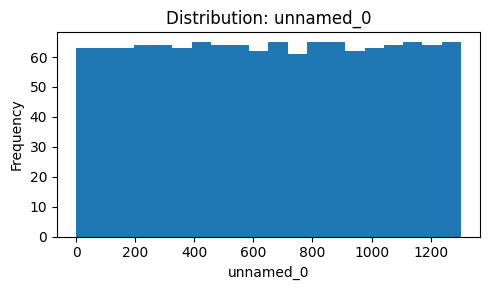

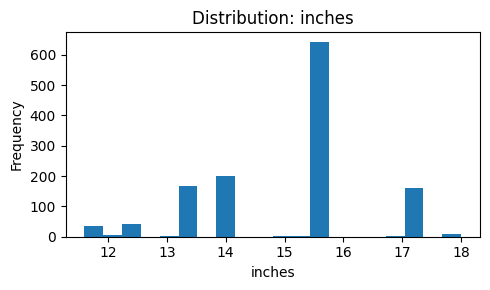

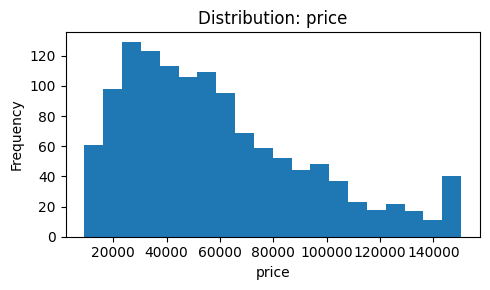

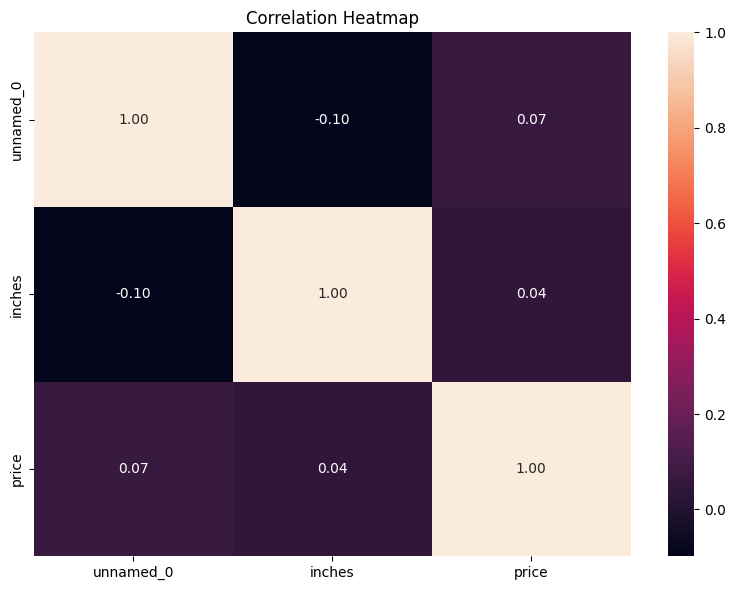


Report saved → report_laptopData.html
Cleaned CSV  → cleaned_laptopData.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Both files downloaded!
🎉 All done — your data is clean.


In [ ]:
import subprocess
subprocess.run(["pip","install","pandas","numpy","matplotlib","scipy","openpyxl","-q"],
               capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, re, base64
from io import BytesIO
from datetime import datetime
from scipy import stats as sp_stats

warnings.filterwarnings("ignore")
print("✅ Libraries ready!\n")

# ── Upload your file ──────────────────────────────────────────
from google.colab import files
print("Dataset")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

if   filename.endswith(".csv"):               df_raw = pd.read_csv(filename, encoding='latin1')
elif filename.endswith((".xlsx",".xls")):     df_raw = pd.read_excel(filename)
elif filename.endswith(".json"):              df_raw = pd.read_json(filename)
else: raise ValueError("Upload a CSV file,xls,json")

print(f"\n✅ Loaded: {filename}")
print(f"   Rows    : {df_raw.shape[0]}")
print(f"   Columns : {df_raw.shape[1]}")
print(f"   Nulls   : {df_raw.isnull().sum().sum()}")
print(f"   Dupes   : {df_raw.duplicated().sum()}")
print("\nFirst 5 rows:")
display(df_raw.head())

# ── Auto-detect special columns ───────────────────────────────
def detect_date_cols(df):
    found = []
    for col in df.select_dtypes(include="object").columns:
        sample = df[col].dropna().head(20)
        parsed = pd.to_datetime(sample, errors="coerce", infer_datetime_format=True)
        if parsed.notna().sum() / max(len(sample),1) > 0.6:
            found.append(col)
    return found

def detect_email_cols(df):
    found = []
    pat = r"[\w\.-]+@[\w\.-]+\.\w{2,}"
    for col in df.select_dtypes(include="object").columns:
        sample = df[col].dropna().head(20).astype(str)
        if sample.str.contains(pat, na=False).mean() > 0.5:
            found.append(col)
    return found

auto_date_cols  = detect_date_cols(df_raw)
auto_email_cols = detect_email_cols(df_raw)
print(f"\n🔍 Date columns detected  : {auto_date_cols  or 'none'}")
print(f"🔍 Email columns detected : {auto_email_cols or 'none'}")

# ── Config (edit if needed) ───────────────────────────────────
base = filename.rsplit(".",1)[0]
CONFIG = {
    "missing_numeric_strategy" : "median",   # mean | median | mode | drop
    "missing_cat_strategy"     : "mode",     # mode | constant | drop
    "missing_constant"         : "UNKNOWN",
    "drop_col_threshold"       : 0.6,
    "remove_duplicates"        : True,
    "duplicate_keep"           : "first",
    "outlier_method"           : "iqr",      # iqr | zscore | none
    "outlier_action"           : "clip",     # clip | remove
    "iqr_multiplier"           : 1.5,
    "zscore_threshold"         : 3.0,
    "strip_whitespace"         : True,
    "standardize_case"         : "title",    # lower | upper | title | none
    "email_columns"            : auto_email_cols,
    "date_columns"             : auto_date_cols,
    "date_output_format"       : "%Y-%m-%d",
    "standardize_col_names"    : True,
    "output_csv"               : f"cleaned_{base}.csv",
    "output_report"            : f"report_{base}.html",
}

# ── AutoCleaner ───────────────────────────────────────────────
class AutoCleaner:
    def __init__(self, df, cfg):
        self.df, self.cfg, self.log = df.copy(), cfg, []
        self.stats = {
            "initial_rows"  : len(df),
            "initial_cols"  : len(df.columns),
            "initial_nulls" : int(df.isnull().sum().sum()),
            "initial_dupes" : int(df.duplicated().sum()),
        }

    def _log(self, msg):
        self.log.append(f"[{datetime.now():%H:%M:%S}] {msg}")
        print(f"  → {msg}")

    def _snake(self, s):
        s = re.sub(r"[^\w\s]","",str(s)).strip()
        return re.sub(r"\s+","_",s).lower()

    def standardize_col_names(self):
        rename = {c: self._snake(c) for c in self.df.columns}
        self.df.rename(columns=rename, inplace=True)
        changed = {k:v for k,v in rename.items() if k!=v}
        if changed: self._log(f"Renamed {len(changed)} columns → snake_case.")
        return self

    def drop_high_null_cols(self):
        thr = self.cfg["drop_col_threshold"]
        drop = self.df.isnull().mean()
        drop = drop[drop > thr].index.tolist()
        if drop:
            self.df.drop(columns=drop, inplace=True)
            self._log(f"Dropped {len(drop)} column(s) with >{thr*100:.0f}% nulls: {drop}")
        return self

    def remove_duplicates(self):
        before = len(self.df)
        self.df.drop_duplicates(keep=self.cfg["duplicate_keep"], inplace=True)
        n = before - len(self.df)
        self.stats["dupes_removed"] = n
        self._log(f"Removed {n} duplicate row(s).")
        return self

    def parse_dates(self):
        fmt = self.cfg["date_output_format"]
        for col in [self._snake(c) for c in self.cfg["date_columns"]]:
            if col not in self.df.columns: continue
            self.df[col] = pd.to_datetime(
                self.df[col], infer_datetime_format=True, errors="coerce"
            ).dt.strftime(fmt)
            self._log(f'Parsed "{col}" → {fmt}.')
        return self
    def clean_strings(self):

      strip = self.cfg["strip_whitespace"]
      case  = self.cfg["standardize_case"]

      ecols = {self._snake(c) for c in self.cfg["email_columns"]}

      for col in self.df.select_dtypes(include="object").columns:

          # convert to string safely
          self.df[col] = self.df[col].astype(str)

          # remove spaces
          if strip:
              self.df[col] = self.df[col].str.strip()

          # skip email columns
          if col not in ecols:

              if case == "lower":
                  self.df[col] = self.df[col].str.lower()

              elif case == "upper":
                  self.df[col] = self.df[col].str.upper()

              elif case == "title":
                  self.df[col] = self.df[col].str.title()

      # email cleaning
      for col in ecols:

          if col not in self.df.columns:
              continue

          self.df[col] = self.df[col].astype(str).str.lower()

          bad = (
              self.df[col].notna()
              &
              ~self.df[col].str.match(
                  r"^[\w\.-]+@[\w\.-]+\.\w{2,}$",
                  na=False
              )
          )

          if bad.sum():

              self.df.loc[bad, col] = np.nan

              self._log(
                  f'Invalidated {bad.sum()} bad email(s) in "{col}".'
              )

      self._log(
          f"Strings cleaned (strip={strip}, case={case})."
      )

      return self


    def infer_types(self):
        n = 0
        for col in self.df.select_dtypes(include="object").columns:
            num = pd.to_numeric(self.df[col], errors="coerce")
            if num.notna().sum()/max(len(self.df),1) > 0.8:
                self.df[col] = num; n += 1
        if n: self._log(f"Auto-converted {n} column(s) to numeric.")
        return self

    def handle_missing(self):
        ns, cs = self.cfg["missing_numeric_strategy"], self.cfg["missing_cat_strategy"]
        const  = self.cfg["missing_constant"]
        filled = 0
        for col in self.df.select_dtypes(include=np.number).columns:
            n = self.df[col].isna().sum()
            if n == 0: continue
            if ns=="mean":   self.df[col].fillna(self.df[col].mean(),   inplace=True)
            elif ns=="median": self.df[col].fillna(self.df[col].median(),inplace=True)
            elif ns=="mode":
                m=self.df[col].mode()
                if len(m): self.df[col].fillna(m[0], inplace=True)
            elif ns=="drop": self.df.dropna(subset=[col], inplace=True)
            filled += n
        for col in self.df.select_dtypes(include="object").columns:
            n = self.df[col].isna().sum()
            if n == 0: continue
            if cs=="mode":
                m=self.df[col].mode()
                if len(m): self.df[col].fillna(m[0], inplace=True)
            elif cs=="constant": self.df[col].fillna(const, inplace=True)
            elif cs=="drop":     self.df.dropna(subset=[col], inplace=True)
            filled += n
        self.stats["nulls_filled"] = filled
        self._log(f"Filled {filled} missing value(s) — numeric:{ns}, cat:{cs}.")
        return self

    def handle_outliers(self):
        method = self.cfg["outlier_method"]
        action = self.cfg["outlier_action"]
        if method=="none": return self
        total = 0
        for col in self.df.select_dtypes(include=np.number).columns:
            if method=="iqr":
                q1,q3 = self.df[col].quantile(.25), self.df[col].quantile(.75)
                lo = q1 - self.cfg["iqr_multiplier"]*(q3-q1)
                hi = q3 + self.cfg["iqr_multiplier"]*(q3-q1)
            else:
                thr = self.cfg["zscore_threshold"]
                z   = np.abs(sp_stats.zscore(self.df[col].dropna()))
                lo  = self.df[col].dropna()[z<thr].min()
                hi  = self.df[col].dropna()[z<thr].max()
            mask = (self.df[col]<lo)|(self.df[col]>hi)
            n = mask.sum()
            if n==0: continue
            total += n
            if action=="clip":   self.df[col] = self.df[col].clip(lo, hi)
            elif action=="remove": self.df = self.df[~mask]
        self.stats["outliers_handled"] = total
        self._log(f"Outliers ({method}/{action}): {total} value(s) handled.")
        return self

    def run(self):
        print("\n" + "="*50)
        print("  AutoCleaner running on:", filename)
        print("="*50)
        (self.standardize_col_names()
             .drop_high_null_cols()
             .remove_duplicates()
             .parse_dates()
             .clean_strings()
             .infer_types()
             .handle_missing()
             .handle_outliers())
        self.stats.update({
            "final_rows"  : len(self.df),
            "final_cols"  : len(self.df.columns),
            "final_nulls" : int(self.df.isnull().sum().sum()),
        })
        print("="*50 + "\n✅ Done!\n")
        return self.df

# ── Run ───────────────────────────────────────────────────────
cleaner  = AutoCleaner(df_raw, CONFIG)
df_clean = cleaner.run()
s        = cleaner.stats

print(f"  Rows          : {s['initial_rows']}  →  {s['final_rows']}")
print(f"  Columns       : {s['initial_cols']}  →  {s['final_cols']}")
print(f"  Nulls         : {s['initial_nulls']}  →  {s['final_nulls']}")
print(f"  Dupes removed : {s.get('dupes_removed',0)}")
print(f"  Outliers fixed: {s.get('outliers_handled',0)}")
print("\nCleaned preview:")
display(df_clean.head(10))

# ── 📊 SHOW GRAPHS IN NOTEBOOK (no changes to your logic) ──

# 1) Missing values BEFORE vs AFTER
before_nulls = df_raw.isnull().sum()
after_nulls  = df_clean.isnull().sum()

cols = [col for col in before_nulls.index
        if col in after_nulls.index and before_nulls[col] > 0]

if len(cols) == 0:
    print("✅ No missing values found — nothing to plot.")
else:
    x = np.arange(len(cols))

    plt.figure(figsize=(10,5))

    plt.bar(x - 0.2, before_nulls[cols], width=0.4, label='Before')
    plt.bar(x + 0.2, after_nulls[cols], width=0.4, label='After')

    plt.xticks(x, cols, rotation=45, ha='right')

    plt.title("Missing Values — Before vs After")
    plt.xlabel("Columns")
    plt.ylabel("Count")

    plt.legend()
    plt.tight_layout()
    plt.show()


# 2) Show distributions for a few numeric columns (always visible)
num_cols = df_clean.select_dtypes(include=np.number).columns[:4]

if len(num_cols) == 0:
    print("ℹ️ No numeric columns to plot.")
else:
    for col in num_cols:
        plt.figure(figsize=(5,3))
        plt.hist(df_clean[col].dropna(), bins=20)
        plt.title(f"Distribution: {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()


# 3) Correlation heatmap (only if 2+ numeric cols)
num_df = df_clean.select_dtypes(include=np.number)

if num_df.shape[1] > 1:
    import seaborn as sns  # safe to import here if not already
    plt.figure(figsize=(8,6))
    sns.heatmap(num_df.corr(), annot=True, fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Not enough numeric columns for correlation heatmap.")


def fig_to_b64(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=120, facecolor="#0f172a")
    buf.seek(0)
    return base64.b64encode(buf.read()).decode()

# ---------------- Chart 1 ----------------

before_nulls = df_raw.isnull().sum()
after_nulls  = df_clean.isnull().sum()

# take columns that had nulls before
cols = before_nulls[before_nulls > 0].index.tolist()

fig1, ax1 = plt.subplots(figsize=(10,5), facecolor="#0f172a")

ax1.set_facecolor("#1e293b")

# if no nulls exist
if len(cols) == 0:

    ax1.axis("off")

    ax1.text(
        0.5,
        0.5,
        "✅ No Missing Values Found In Dataset",
        ha="center",
        va="center",
        fontsize=22,
        color="white",
        fontweight="bold"
    )

else:

    x = np.arange(len(cols))

    before_vals = before_nulls[cols].values

    after_vals = [0 for _ in cols]

    ax1.bar(
    x - 0.2,
    before_vals,
    width=0.4,
    label="Before",
    color="#ef4444"
    )

    ax1.bar(
    x + 0.2,
    [0.3 for _ in cols],
    width=0.4,
    label="After",
    color="#22c55e"
    )

    ax1.set_xticks(x)

    ax1.set_xticklabels(
        cols,
        rotation=45,
        ha="right",
        color="white"
    )

    ax1.set_ylabel("Null Count", color="white")

    ax1.set_title(
        "Missing Values — Before vs After",
        color="white",
        fontsize=18
    )

    ax1.tick_params(colors="#cbd5e1")

    ax1.legend()

img1 = fig_to_b64(fig1)

plt.close(fig1)

# Chart 2 — data types
dtype_counts = df_clean.dtypes.astype(str).value_counts()
fig2, ax2 = plt.subplots(figsize=(4, 3.8), facecolor="#0f172a")
ax2.set_facecolor("#0f172a")
cols = ["#38bdf8","#f59e0b","#a78bfa","#34d399","#f87171"]
ax2.pie(dtype_counts.values, labels=dtype_counts.index, autopct="%1.0f%%",
        colors=cols[:len(dtype_counts)],
        textprops={"color":"white","fontsize":8},
        wedgeprops={"edgecolor":"#0f172a","linewidth":2})
ax2.set_title("Column types", color="white", fontsize=11, pad=10)
img2 = fig_to_b64(fig2); plt.close(fig2)

# Chart 3 — numeric histograms
num_cols = df_clean.select_dtypes(include=np.number).columns[:4]
if len(num_cols):
    fig3, axes = plt.subplots(1, len(num_cols),
                              figsize=(10, 3.2), facecolor="#0f172a")
    if len(num_cols)==1: axes=[axes]
    for ax, col in zip(axes, num_cols):
        ax.set_facecolor("#1e293b")
        ax.hist(df_clean[col].dropna(), bins=20, color="#38bdf8",
                edgecolor="#0f172a", alpha=.85)
        ax.set_title(col, color="white", fontsize=8)
        ax.tick_params(colors="#64748b", labelsize=7)
        ax.spines[:].set_color("#334155")
    plt.suptitle("Numeric distributions (after cleaning)",
                 color="white", fontsize=10, y=1.02)
    img3 = fig_to_b64(fig3); plt.close(fig3)
    img3_tag = f'<img src="data:image/png;base64,{img3}>'
else:
    img3_tag = "<p style='color:#64748b'>No numeric columns to plot.</p>"

def card(icon, label, val, color="#38bdf8"):
    return f"""<div style="background:#1e293b;border-radius:12px;padding:18px 22px;
border-left:4px solid {color};min-width:148px">
<div style="font-size:20px">{icon}</div>
<div style="font-size:24px;font-weight:700;color:{color};margin:6px 0">{val}</div>
<div style="font-size:11px;color:#94a3b8;text-transform:uppercase;letter-spacing:.06em">{label}</div>
</div>"""

log_li = "".join(
    f'<li style="padding:4px 0;border-bottom:1px solid #1e293b;color:#cbd5e1">{e}</li>'
    for e in cleaner.log)
desc_html = df_clean.describe(include="all").T.round(2).to_html(classes="dt", border=0)
rows_rm  = s["initial_rows"] - s["final_rows"]
null_fix = s["initial_nulls"] - s["final_nulls"]

html = f"""<!DOCTYPE html><html lang="en"><head><meta charset="UTF-8">
<title>Automated Data Cleaning and Analysis System</title>
<link href="https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@400;600&family=Syne:wght@700;800&display=swap" rel="stylesheet">
<style>
*{{box-sizing:border-box;margin:0;padding:0}}
body{{font-family:'Syne',sans-serif;background:#0f172a;color:#e2e8f0;padding:40px 6%}}
h1{{font-size:2em;font-weight:800;color:#fff}}
h1 span{{color:#38bdf8}}
.sub{{color:#64748b;font-size:.82em;margin-top:6px;font-family:'JetBrains Mono',monospace}}
.cards{{display:flex;flex-wrap:wrap;gap:14px;margin:28px 0}}
h2{{font-size:.9em;color:#38bdf8;text-transform:uppercase;letter-spacing:.08em;
    margin:32px 0 12px;border-bottom:1px solid #1e293b;padding-bottom:8px}}
img{{max-width:100%;border-radius:10px;margin:8px 0;display:block}}
.charts{{display:flex;gap:16px;flex-wrap:wrap;align-items:flex-start}}
.log{{list-style:none;background:#0a1628;border-radius:10px;padding:14px 18px;
      font-family:'JetBrains Mono',monospace;font-size:.75em;max-height:240px;overflow-y:auto}}
.table-container{{width:100%;overflow-x:auto;margin-top:20px;border-radius:10px;}} .dt{{width:100%;border-collapse:collapse;background:#1e293b;font-size:14px;color:white;}} .dt thead{{background:#334155;}}

.dt th{{padding:12px;border:1px solid #475569;text-align:left;color:#38bdf8;}} .dt td{{padding:10px;border:1px solid #334155;color:#e2e8f0;}}

.dt tr:nth-child(even){{background:#0f172a;}}
footer{{margin-top:48px;color:#334155;font-size:.75em;text-align:center}}
</style></head><body>
<h1>📊 Automated Data Cleaning and Analysis System</h1>
<p class="sub">File: {filename} &nbsp;|&nbsp; {datetime.now():%Y-%m-%d %H:%M:%S}</p>

<h2>Summary</h2>
<div class="cards">
{card("📋","Initial rows",   f"{s['initial_rows']:,}",            "#38bdf8")}
{card("✅","Final rows",     f"{s['final_rows']:,}",              "#22c55e")}
{card("🗑️","Rows removed",  f"{rows_rm:,}",                      "#f87171")}
{card("🔧","Nulls fixed",    f"{null_fix:,}",                     "#f59e0b")}
{card("👥","Dupes removed",  f"{s.get('dupes_removed',0):,}",     "#a78bfa")}
{card("📐","Outliers fixed", f"{s.get('outliers_handled',0):,}",  "#fb923c")}
{card("📊","Final columns",  f"{s['final_cols']:,}",              "#34d399")}
{card("🔢","Remaining nulls",f"{s['final_nulls']:,}",
      "#22c55e" if s["final_nulls"]==0 else "#f59e0b")}
</div>

<h2>Visualisations</h2>
<div class="charts">
  <img src="data:image/png;base64,{img1}" style="flex:2">
  <img src="data:image/png;base64,{img2}" style="flex:1;max-width:240px">
</div>
{img3_tag}

<h2>Column statistics</h2>

<div class="table-container">
{desc_html}
</div>

<h2>Change log</h2>
<ul class="log">{log_li}</ul>

<footer>AutoCleaner — {filename}</footer>
</body></html>"""

with open(CONFIG["output_report"],"w",encoding="utf-8") as f:
    f.write(html)
print(f"\nReport saved → {CONFIG['output_report']}")

# ── Save & download ───────────────────────────────────────────
df_clean.to_csv(CONFIG["output_csv"], index=False)
print(f"Cleaned CSV  → {CONFIG['output_csv']}")

files.download(CONFIG["output_csv"])
files.download(CONFIG["output_report"])
print("\n📥 Both files downloaded!")
print("🎉 All done — your data is clean.")

In [ ]:
# 2nd Type